In [1]:
import pandas as pd

In [2]:
# 1. Column Names
# Display all column names. Identify columns having leading/trailing spaces and
# rename all columns into a consistent snake_case format.

df = pd.read_csv("C:\\Users\\bhoom\\Downloads\\matplotlib_messy_sales_2000 - matplotlib_messy_sales_2000.csv")

df.head()

,Customer ID,Order Date,City,Product Category,Customer Segment,Gender,Sales Channel,Age,Units Sold,Unit Price,Discount %,Customer Rating,Is Active,Returned,Payment Method,Gross Sales,Discount Amount,Revenue,Cost,Profit
0,CUST00594,2025-05-05 00:00:00,Mumbai,Clothing,premium,Male,Retail,36,8,24235.73,22.91,1.9,1,0,UPI,193885.84,44419.25,149466.59,88698.45,60768.14
1,CUST01103,2025-10-22 00:00:00,Mumbai,Clothing,Premium,Female,Corporate,38,5,16789.55,10.59,4.3,1,0,Cash,83947.75,8890.07,75057.68,61426.31,13631.37
2,CUST00690,2025-04-24 00:00:00,Delhi,Home & Kitchen,Regular,Male,Retail,65,2,24579.97,36.22,4.5,1,0,Debit Card,49159.94,17805.73,31354.21,24948.21,6406.00
3,CUST00215,2025-05-17 00:00:00,Chennai,Electronics,Regular,Male,Corporate,34,9,6240.13,20.44,3.9,1,0,Net Banking,56161.17,11479.34,NaN,26470.33,18211.50
4,CUST01270,2025-08-30 00:00:00,Delhi,Clothing,Budget,Female,Corporate,41,1,23491.23,10.48,3.7,1,0,Net Banking,23491.23,2461.88,21029.35,12312.38,8716.97


In [3]:
space_columns = [col for col in df.columns if col != col.strip()]
space_columns

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_"))

In [4]:
df.columns.tolist()

['customer_id',
 'order_date',
 'city',
 'product_category',
 'customer_segment',
 'gender',
 'sales_channel',
 'age',
 'units_sold',
 'unit_price',
 'discount_%',
 'customer_rating',
 'is_active',
 'returned',
 'payment_method',
 'gross_sales',
 'discount_amount',
 'revenue',
 'cost',
 'profit']

In [5]:
# 2. Duplicate Records
# Find the number of duplicate rows. Remove the duplicate records and verify that no
# duplicates remain.

df.duplicated().sum()

np.int64(20)

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# 3. Missing Values
# Display the missing-value count and missing-value percentage for every column.
missing_count = df.isna().sum()
missing_count

customer_id          0
order_date           4
city                25
product_category    24
customer_segment     0
gender               0
sales_channel        0
age                 27
units_sold           4
unit_price          24
discount_%          28
customer_rating     25
is_active            0
returned             0
payment_method      25
gross_sales          0
discount_amount      0
revenue             25
cost                 0
profit               0
dtype: int64

In [9]:
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({"Missing Count": missing_count,"Missing Percentage": missing_percentage})
missing_summary

,Missing Count,Missing Percentage
customer_id,0,0.00
order_date,4,0.20
city,25,1.25
product_category,24,1.20
customer_segment,0,0.00
gender,0,0.00
sales_channel,0,0.00
age,27,1.35
units_sold,4,0.20
unit_price,24,1.20


In [10]:
# 4. Missing Categorical Values
# Handle missing values in city, product_category, and payment_method using an
# appropriate strategy.

df["city"] = df["city"].fillna(df["city"].mode()[0])
df["product_category"] = df["product_category"].fillna(df["product_category"].mode()[0])
df["payment_method"] = df["payment_method"].fillna(df["payment_method"].mode()[0])

In [11]:
df[["city", "product_category", "payment_method"]].isnull().sum()

city                0
product_category    0
payment_method      0
dtype: int64

In [12]:
# 5. Missing Numerical Values
# Handle missing values in age, unit_price, discount_pct, customer_rating, and
# revenue. Explain why you selected mean, median, or another method.

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")
df["discount_%"] = pd.to_numeric(df["discount_%"], errors="coerce")
df["customer_rating"] = pd.to_numeric(df["customer_rating"], errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")

df["age"] = df["age"].fillna(df["age"].median())
df["unit_price"] = df["unit_price"].fillna(df["unit_price"].median())
df["discount_%"] = df["discount_%"].fillna(df["discount_%"].median())
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())
df["revenue"] = df["revenue"].fillna(df["revenue"].median())

print(df[[
    "age",
    "unit_price",
    "discount_%",
    "customer_rating",
    "revenue"
]].isnull().sum())

age                0
unit_price         0
discount_%         0
customer_rating    0
revenue            0
dtype: int64


In [13]:
# 6. Date Cleaning
#Convert order_date into a proper datetime format. Identify invalid date values and
#handle them appropriately.

df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

print("Invalid dates:", df["order_date"].isnull().sum())

df = df.dropna(subset=["order_date"])

print("Invalid dates after cleaning:",
      df["order_date"].isnull().sum())

Invalid dates: 25
Invalid dates after cleaning: 0


In [14]:
# 7. Age Cleaning
#The age column contains values such as 25 years, 30 yrs, 45Y, and N/A. Extract the
# numerical age and convert the column into a numeric datatype.

df.loc[:, "age"] = pd.to_numeric(
    df["age"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

print(df["age"].head())
print(df["age"].dtype)

0    36.0
1    38.0
2    65.0
3    34.0
4    41.0
Name: age, dtype: float64
float64


In [15]:
# 8. Age Outliers
# Identify unrealistic ages such as 120, 150, and 200. Detect them using the IQR
# method and handle them appropriately.

Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

outliers = df[(df["age"] < lower) | (df["age"] > upper)]

print("Age outliers:")
print(outliers["age"])

Lower limit: -6.5
Upper limit: 93.5
Age outliers:
193     150.0
256     120.0
323     120.0
467     120.0
534     200.0
647     120.0
777     150.0
869     150.0
991     150.0
1023    120.0
1532    150.0
1731    120.0
2000    120.0
Name: age, dtype: float64


In [16]:
# 9. Unit Price Cleaning
# The unit_price column contains values such as ₹15000, $20000, 25000 INR, and 10k.
# Convert all valid values into a single numeric format.

def clean_unit_price(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()
    value = value.replace("₹", "")
    value = value.replace("$", "")
    value = value.replace("inr", "")
    value = value.replace(",", "")
    value = value.strip()
    
    if value.endswith("k"):
        value = value[:-1]
        return float(value) * 1000

    return float(value)

df["unit_price"] = df["unit_price"].apply(clean_unit_price)
df["unit_price"].head()

0    24235.73
1    16789.55
2    24579.97
3     6240.13
4    23491.23
Name: unit_price, dtype: float64

In [17]:
# 10. Unit Price Outliers
# Detect extreme unit_price values using the IQR method. Compare the number of
# outliers before and after treatment.

Q1 = df["unit_price"].quantile(0.25)
Q3 = df["unit_price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers_before = (
    (df["unit_price"] < lower_limit) | (df["unit_price"] > upper_limit)).sum()

print("Outliers before treatment:", outliers_before)

Q1: 7767.6900000000005
Q3: 22602.48
IQR: 14834.789999999999
Lower Limit: -14484.494999999997
Upper Limit: 44854.66499999999
Outliers before treatment: 14


In [18]:
# 11. Units Sold Cleaning
# Clean values such as 5 units, 10 pcs, twenty, N/A, and 3 and convert the column into
# a numeric datatype.

import numpy as np
word_numbers = {
    "zero": 0,
    "one": 1,
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10,
    "twenty": 20
}

def clean_units_sold(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if value in ["n/a", "na", "nan", ""]:
        return np.nan

    if value in word_numbers:
        return word_numbers[value]

    value = value.replace("units", "")
    value = value.replace("pcs", "")
    value = value.strip()

    return float(value)

df["units_sold"] = df["units_sold"].apply(clean_units_sold)

df["units_sold"] = pd.to_numeric(df["units_sold"], errors="coerce")

print(df["units_sold"].head())
print(df["units_sold"].dtype)

0    8.0
1    5.0
2    2.0
3    9.0
4    1.0
Name: units_sold, dtype: float64
float64


In [20]:
# 12. Discount Cleaning
# Clean values such as 10%, 20 percent, 5 %, none, and N/A. Convert the final
# discount_pct column into numeric values between 0 and 100.

def clean_discount(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if value in ["none", "n/a", "na", "nan", ""]:
        return np.nan

    value = value.replace("%", "")
    value = value.replace("percent", "")
    value = value.strip()

    return float(value)

df["discount_%"] = df["discount_%"].apply(clean_discount)

df["discount_%"] = pd.to_numeric(df["discount_%"], errors="coerce")

print(df["discount_%"].head())
print(df["discount_%"].dtype)

0    22.91
1    10.59
2    36.22
3    20.44
4    10.48
Name: discount_%, dtype: float64
float64


In [21]:
# 13. Discount Outliers
# Identify invalid discount values such as 75, 90, and 120. Determine which values are
# unrealistic and handle them.

invalid_discount = df[
    (df["discount_%"] < 0) |
    (df["discount_%"] > 100)
]

print(invalid_discount[["discount_%"]])

      discount_%
92         120.0
567        120.0
884        120.0
1419       120.0
1994       120.0


In [22]:
df.loc[
    (df["discount_%"] < 0) |
    (df["discount_%"] > 100),
    "discount_%"
] = np.nan

In [23]:
print("Invalid values after treatment:",
      ((df["discount_%"] < 0) |
       (df["discount_%"] > 100)).sum())

Invalid values after treatment: 0


In [27]:
# 14. City Standardization
# Standardize inconsistent city values such as:
# o Mumbai
# o mumbai
# o MUMBAI
# o Mumbai
# o Bangalore
# o bangalore
# o Hyderbad

df["city"] = df["city"].str.strip().str.lower()

df["city"] = df["city"].replace({
    "mumbai": "Mumbai",
    "delhi": "Delhi",
    "chennai": "Chennai",
    "hyderabad": "Hyderabad",
    "pune": "Pune",
    "bengaluru": "Bangalore",
    "bangalore": "Bangalore"
})

print(df["city"].unique())

['Mumbai' 'Delhi' 'Chennai' 'Hyderabad' 'Pune' 'Bangalore']


In [28]:
# 15. Product Category Cleaning
# Standardize values such as Electronics, electronics, ELECTRONICS, Home and Kitchen,
# home & kitchen, and Beauty .

df["product_category"] = df["product_category"].str.strip().str.lower()

df["product_category"] = df["product_category"].replace({
    "electronics": "Electronics",
    "home and kitchen": "Home & Kitchen",
    "home & kitchen": "Home & Kitchen",
    "beauty": "Beauty"
})

print(df["product_category"].unique())

['clothing' 'Home & Kitchen' 'Electronics' 'sports' 'Beauty']


In [29]:
# 16. Gender Cleaning
# Standardize values such as Male, male, Male, FEMALE, female , M, and F into
# consistent categories.

df["gender"] = df["gender"].str.strip().str.lower()

df["gender"] = df["gender"].replace({
    "male": "Male",
    "m": "Male",
    "female": "Female",
    "f": "Female"
})
print(df["gender"].unique())

['Male' 'Female' 'other']


In [30]:
# 17. Customer Segment Cleaning
# Identify invalid values such as Prem, Reg, VIP, and Unknown. Map valid variations to
# the correct categories and decide how to handle invalid categories.

df["customer_segment"] = df["customer_segment"].str.strip().str.lower()

df["customer_segment"] = df["customer_segment"].replace({
    "prem": "Premium",
    "premium": "Premium",
    "reg": "Regular",
    "regular": "Regular",
    "vip": "VIP"
})

df["customer_segment"] = df["customer_segment"].replace({
    "unknown": np.nan
})
print(df["customer_segment"].unique())

['Premium' 'Regular' 'budget']


In [34]:
# 18. Binary Column Cleaning
# Clean is_active and returned, where values contain combinations of:
# o 0/1
# o Yes/No
# o Y/N
# o Active/Inactive
# o Returned/Not Returned

df["is_active"].value_counts()

is_active
1    1468
0     507
Name: count, dtype: int64

In [37]:
df["is_active"] = (
    df["is_active"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "active": 1,
        "yes": 1,
        "y": 1,
        "1": 1,
        "inactive": 0,
        "no": 0,
        "n": 0,
        "0": 0
    })
)

df["returned"] = (
    df["returned"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "returned": 1,
        "yes": 1,
        "y": 1,
        "1": 1,
        "not returned": 0,
        "no": 0,
        "n": 0,
        "0": 0
    })
)

df["is_active"] = pd.to_numeric(df["is_active"], errors="coerce")
df["returned"] = pd.to_numeric(df["returned"], errors="coerce")

C:\Users\bhoom\AppData\Local\Temp\ipykernel_23124\3803413926.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({
C:\Users\bhoom\AppData\Local\Temp\ipykernel_23124\3803413926.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [38]:
# 19. Data-Type Validation
# After cleaning, display df.info() and verify that:
# o Dates are datetime
# o Numerical columns are numeric
# o Binary columns contain only 0 and 1
# o Categorical columns contain clean strings

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1975 entries, 0 to 2019
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       1975 non-null   object        
 1   order_date        1975 non-null   datetime64[ns]
 2   city              1975 non-null   object        
 3   product_category  1975 non-null   object        
 4   customer_segment  1975 non-null   object        
 5   gender            1975 non-null   object        
 6   sales_channel     1975 non-null   object        
 7   age               1975 non-null   float64       
 8   units_sold        1971 non-null   float64       
 9   unit_price        1975 non-null   float64       
 10  discount_%        1970 non-null   float64       
 11  customer_rating   1975 non-null   float64       
 12  is_active         1975 non-null   int64         
 13  returned          1975 non-null   int64         
 14  payment_method    1975 non-nu

In [39]:
numeric_columns = [
    "age",
    "units_sold",
    "unit_price",
    "discount_%",
    "customer_rating",
    "gross_sales",
    "discount_amount",
    "revenue",
    "cost",
    "profit"
]

print(df[numeric_columns].dtypes)

age                float64
units_sold         float64
unit_price         float64
discount_%         float64
customer_rating    float64
gross_sales        float64
discount_amount    float64
revenue            float64
cost               float64
profit             float64
dtype: object


In [40]:
print("is_active:", df["is_active"].dropna().unique())
print("returned:", df["returned"].dropna().unique())

is_active: [1 0]
returned: [0 1]


In [41]:
print(df["is_active"].dropna().isin([0, 1]).all())
print(df["returned"].dropna().isin([0, 1]).all())

True
True


In [42]:
categorical_columns = [
    "city",
    "product_category",
    "customer_segment",
    "gender",
    "sales_channel",
    "payment_method"
]

for col in categorical_columns:
    print(col, ":", df[col].dtype)

city : object
product_category : object
customer_segment : object
gender : object
sales_channel : object
payment_method : object


In [43]:
print("\nCategorical columns:")
for col in categorical_columns:
    print(col, ":", df[col].dtype)


Categorical columns:
city : object
product_category : object
customer_segment : object
gender : object
sales_channel : object
payment_method : object


In [44]:
# 20. Final Data Quality Check — Hardest
# Perform a complete final audit of the cleaned dataset:
# o Check duplicate rows
# o Check missing values
# o Check invalid dates
# o Check numerical columns
# o Check outliers
# o Check categorical inconsistencies
# o Check binary values
# o Check datatypes
# o Verify that Revenue, Cost, and Profit are logically consistent

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [45]:
print(df.isnull().sum())

customer_id         0
order_date          0
city                0
product_category    0
customer_segment    0
gender              0
sales_channel       0
age                 0
units_sold          4
unit_price          0
discount_%          5
customer_rating     0
is_active           0
returned            0
payment_method      0
gross_sales         0
discount_amount     0
revenue             0
cost                0
profit              0
dtype: int64


In [47]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
print("Invalid dates:", df["order_date"].isna().sum())

Invalid dates: 0


In [48]:
numeric_columns = [
    "age",
    "units_sold",
    "unit_price",
    "discount_%",
    "customer_rating",
    "gross_sales",
    "discount_amount",
    "revenue",
    "cost",
    "profit"
]

print(df[numeric_columns].dtypes)

age                float64
units_sold         float64
unit_price         float64
discount_%         float64
customer_rating    float64
gross_sales        float64
discount_amount    float64
revenue            float64
cost               float64
profit             float64
dtype: object


In [49]:
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)

age : 13
units_sold : 15
unit_price : 14
discount_% : 5
customer_rating : 0
gross_sales : 17
discount_amount : 109
revenue : 22
cost : 38
profit : 69


In [50]:
categorical_columns = [
    "city",
    "product_category",
    "customer_segment",
    "gender",
    "sales_channel",
    "payment_method"
]

for col in categorical_columns:
    print("\n", col)
    print(df[col].unique())


 city
['Mumbai' 'Delhi' 'Chennai' 'Hyderabad' 'Pune' 'Bangalore']

 product_category
['clothing' 'Home & Kitchen' 'Electronics' 'sports' 'Beauty']

 customer_segment
['Premium' 'Regular' 'budget']

 gender
['Male' 'Female' 'other']

 sales_channel
['Retail' 'Corporate' 'Online' 'Corp' 'retail' 'online' 'offline'
 'ON-LINE']

 payment_method
['UPI' 'Cash' 'Debit Card' 'Net Banking' 'Credit Card']


In [51]:
print("is_active:", df["is_active"].dropna().unique())
print("returned:", df["returned"].dropna().unique())

print(
    "is_active valid:",
    df["is_active"].dropna().isin([0, 1]).all()
)

print(
    "returned valid:",
    df["returned"].dropna().isin([0, 1]).all()
)

is_active: [1 0]
returned: [0 1]
is_active valid: True
returned valid: True


In [54]:
calculated_profit = df["revenue"] - df["cost"]

profit_check = (
    (df["profit"] - calculated_profit).abs() < 0.01
)

print("Profit consistency:", profit_check.all())

print(
    "Inconsistent Profit rows:",
    (~profit_check).sum()
)
revenue_check = df["revenue"] <= df["gross_sales"]

print(
    "Revenue <= Gross Sales:",
    revenue_check.all()
)

print(
    "Invalid Revenue rows:",
    (~revenue_check).sum())

Profit consistency: False
Inconsistent Profit rows: 25
Revenue <= Gross Sales: False
Invalid Revenue rows: 13


In [53]:
revenue_calculated = df["gross_sales"] - df["discount_amount"]

revenue_check = (
    (df["revenue"] - revenue_calculated).abs() < 0.01
)

print("Revenue consistency:", revenue_check.all())
print("Incorrect Revenue rows:", (~revenue_check).sum())


# Profit consistency
profit_calculated = df["revenue"] - df["cost"]

profit_check = (
    (df["profit"] - profit_calculated).abs() < 0.01
)

print("Profit consistency:", profit_check.all())
print("Incorrect Profit rows:", (~profit_check).sum())

Revenue consistency: False
Incorrect Revenue rows: 25
Profit consistency: False
Incorrect Profit rows: 25


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1975 entries, 0 to 2019
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       1975 non-null   object        
 1   order_date        1975 non-null   datetime64[ns]
 2   city              1975 non-null   object        
 3   product_category  1975 non-null   object        
 4   customer_segment  1975 non-null   object        
 5   gender            1975 non-null   object        
 6   sales_channel     1975 non-null   object        
 7   age               1975 non-null   float64       
 8   units_sold        1971 non-null   float64       
 9   unit_price        1975 non-null   float64       
 10  discount_%        1970 non-null   float64       
 11  customer_rating   1975 non-null   float64       
 12  is_active         1975 non-null   int64         
 13  returned          1975 non-null   int64         
 14  payment_method    1975 non-nu

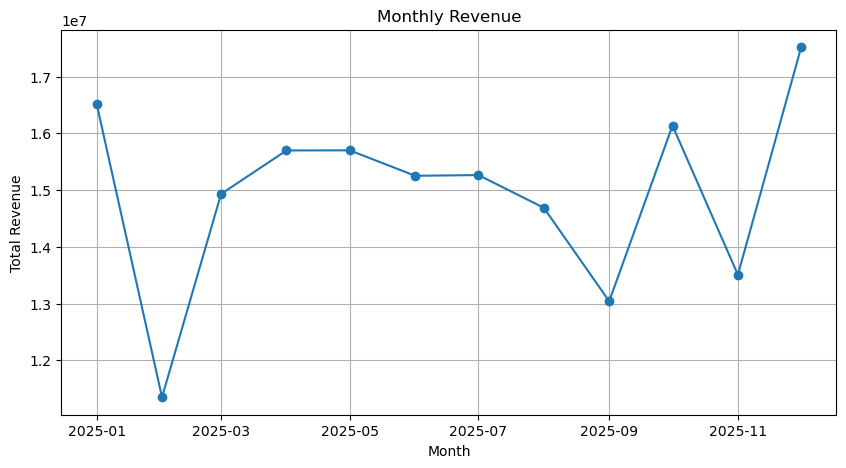

In [56]:
# 1. Monthly Revenue Line Chart
#Using order_date and revenue:
#• Convert order_date to datetime.
#• Calculate total revenue for each month.
#• Create a line chart.
#• Add:
#o Title
#o X-axis label
#o Y-axis label
#o Grid
#o Markers
#Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()

import pandas as pd
import matplotlib.pyplot as plt


df["order_date"] = pd.to_datetime(df["order_date"])

monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

monthly_revenue.index = monthly_revenue.index.to_timestamp()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)

plt.show()

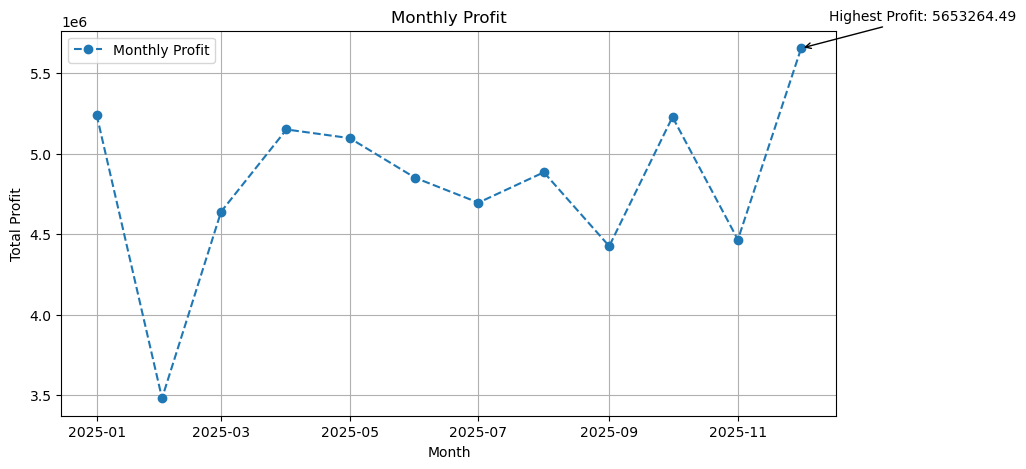

In [57]:
#2. Monthly Profit Line Chart
#Create a line chart showing monthly Profit.
#Requirements:
#• Use a different line style.
#• Add markers.
#• Add a legend.
#• Display the value of the highest-profit month using annotate().
#Commands/concepts: plt.plot(), plt.legend(), plt.annotate()


monthly_profit = df.groupby(
    df["order_date"].dt.to_period("M")
)["profit"].sum()

monthly_profit.index = monthly_profit.index.to_timestamp()

highest_month = monthly_profit.idxmax()
highest_profit = monthly_profit.max()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    linestyle="--",
    marker="o",
    label="Monthly Profit"
)

plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.grid(True)
plt.legend()

plt.annotate(
    f"Highest Profit: {highest_profit:.2f}",
    xy=(highest_month, highest_profit),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)
plt.show()

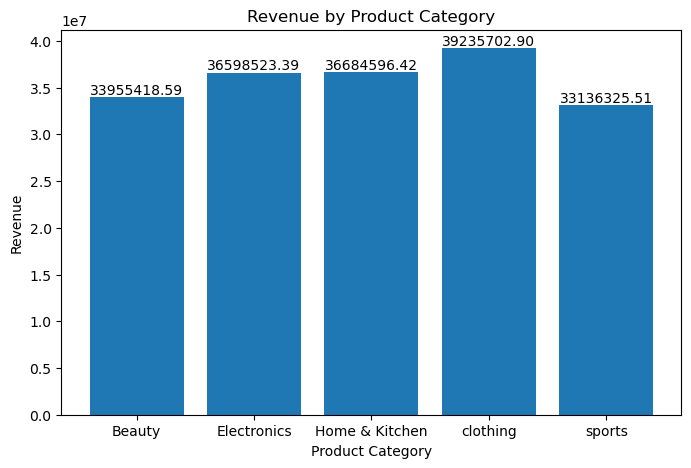

In [58]:
# 3. Revenue by Product Category — Bar Chart
#Calculate total revenue for each product_category.
#Create a bar chart.
#Requirements:
#• X-axis → Product Category
#• Y-axis → Revenue
#• Add title and labels.
#• Display the revenue value above each bar.
#Commands/concepts: plt.bar(), plt.text()


category_revenue = df.groupby("product_category")["revenue"].sum()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

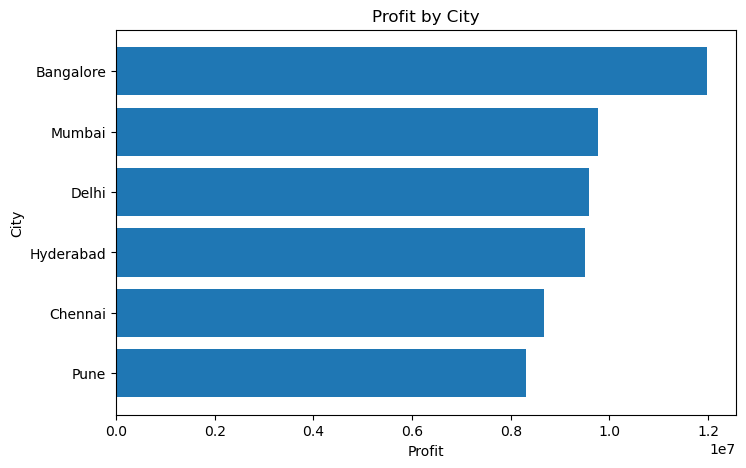

In [59]:
#4. Profit by City — Horizontal Bar Chart
#Calculate total profit for each city.
#Create a horizontal bar chart.
#Requirements:
#• Sort cities by profit.
#• Show the highest-profit city first.
#• Add title and axis labels.
#Commands/concepts: plt.barh(), sort_values()


city_profit = df.groupby("city")["profit"].sum()

city_profit = city_profit.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

plt.barh(city_profit.index, city_profit.values)

plt.gca().invert_yaxis()

plt.title("Profit by City")
plt.xlabel("Profit")
plt.ylabel("City")

plt.show()

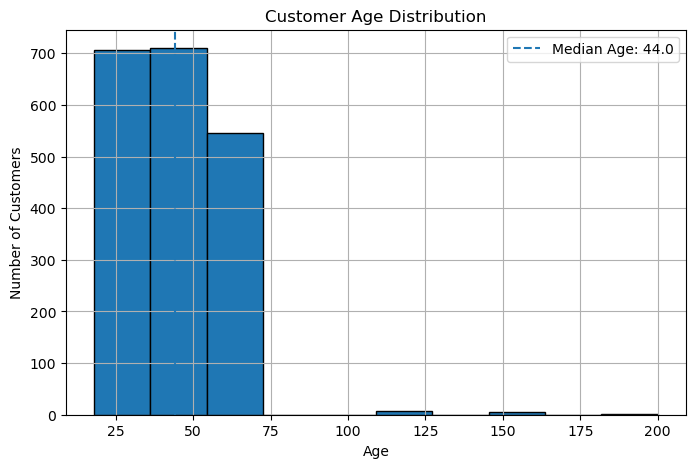

In [60]:
# 5. Customer Age Histogram
#Create a histogram of the age column.
#Requirements:
#• Use 10 bins.
#• Add title.
#• Add X/Y labels.
#• Add grid.
#• Add a vertical line showing the median age.
#Commands/concepts: plt.hist(), plt.axvline()

median_age = df["age"].median()

plt.figure(figsize=(8, 5))

plt.hist(
    df["age"],
    bins=10,
    edgecolor="black"
)

plt.axvline(
    median_age,
    linestyle="--",
    label=f"Median Age: {median_age:.1f}"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.legend()

plt.show()

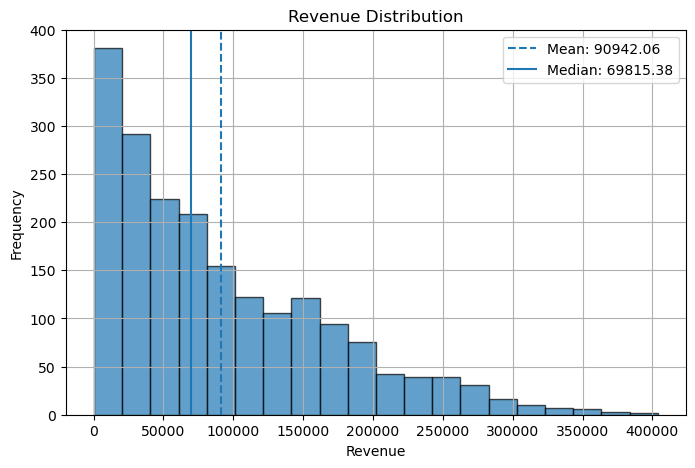

In [61]:
# 6. Revenue Distribution Histogram
#Create a histogram showing the distribution of revenue.
#Requirements:
#• Use 20 bins.
#• Add transparency using alpha.
#• Add grid.
#• Add mean and median lines.
#• Add a legend.
#Commands/concepts:
#plt.hist()
#plt.axvline()
#plt.legend()

mean_revenue = df["revenue"].mean()
median_revenue = df["revenue"].median()

plt.figure(figsize=(8, 5))

plt.hist(
    df["revenue"],
    bins=20,
    alpha=0.7,
    edgecolor="black"
)

plt.axvline(
    mean_revenue,
    linestyle="--",
    label=f"Mean: {mean_revenue:.2f}"
)

plt.axvline(
    median_revenue,
    linestyle="-",
    label=f"Median: {median_revenue:.2f}"
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.grid(True)
plt.legend()

plt.show()

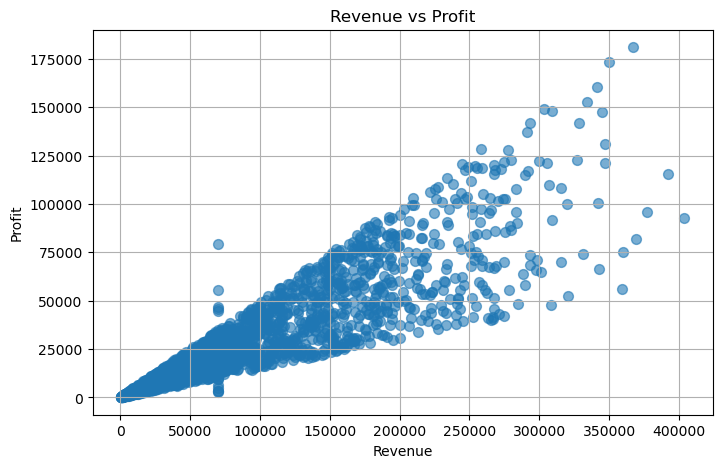

In [62]:
# 7. Revenue vs Profit Scatter Plot
#Create a scatter plot between:
#• X → Revenue
#• Y → Profit
#Requirements:
#• Use different marker size.
#• Add transparency.
#• Add title and axis labels.
#• Add grid.
#Commands/concepts:
#plt.scatter()
#Important parameters to practice:
#s=
#alpha=
#marker=

plt.figure(figsize=(8, 5))

plt.scatter(
    df["revenue"],
    df["profit"],
    s=50,
    alpha=0.6,
    marker="o" 
)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.grid(True)

plt.show()

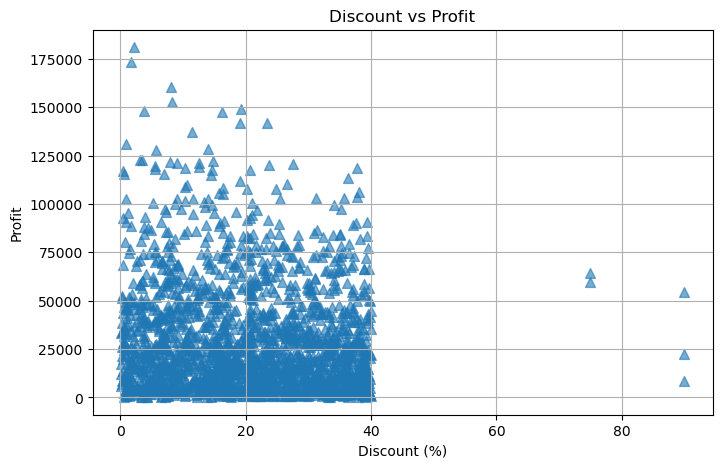

In [63]:
# 8. Discount vs Profit Scatter Plot
#Create a scatter plot between:
#• X → discount_pct
#• Y → profit
#Requirements:
#• Use a different marker.
#• Add transparency.
#• Add title.
#• Add axis labels.
#• Add grid.
#Then answer:
#Does profit appear to decrease as discount increases?

plt.figure(figsize=(8, 5))

plt.scatter(
    df["discount_%"],
    df["profit"],
    s=50,
    alpha=0.6,
    marker="^"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")
plt.grid(True)

plt.show()

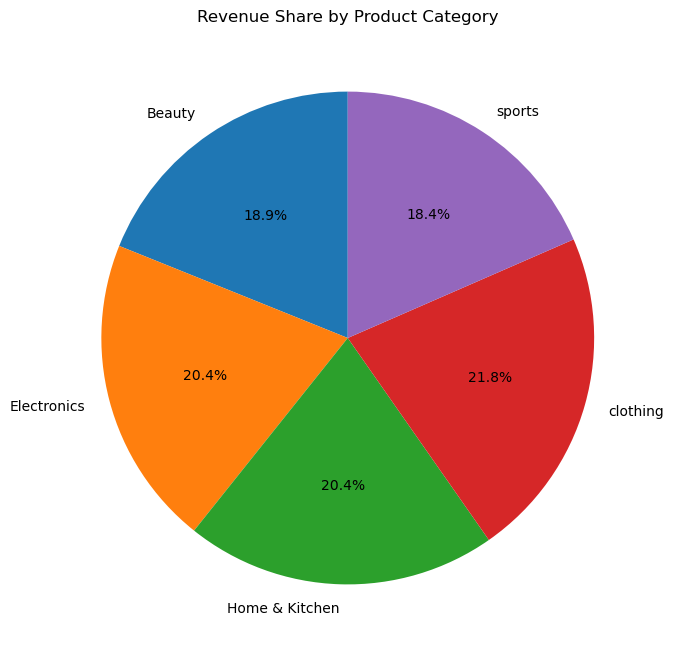

In [64]:
# 9. Revenue Share — Pie Chart
#Calculate total revenue for every product_category.
#Create a pie chart showing each category's contribution.
#Requirements:
#• Display percentages.
#• Display category names.
#• Add a title.
#• Start the first slice from the top.
#Commands/concepts:
#plt.pie()
#Important parameters:
#autopct=
#startangle=
#labels=

category_revenue = df.groupby("product_category")["revenue"].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Product Category")

plt.show()

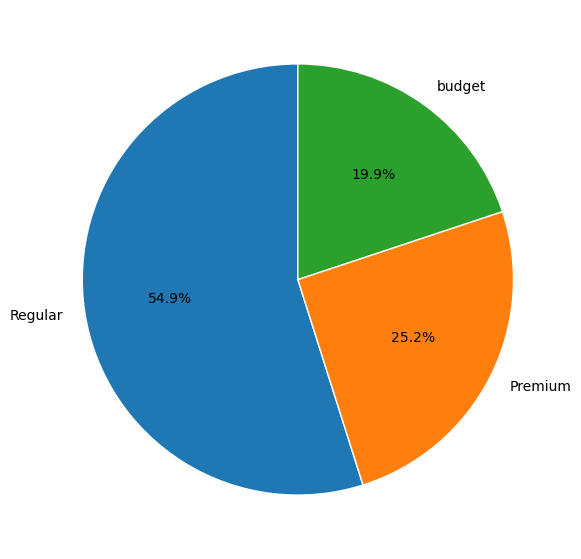

In [66]:
# 10. Customer Segment Pie Chart
#Create a pie chart showing the number of customers/orders in each customer segment.
#Segments:
#• Premium
#• Regular
#• Budget
#Requirements:
#• Show percentage.
#• Add labels.
#• Add title.
#• Make the chart visually clean.
#Question: Which customer segment has the largest share?

segment_count = df["customer_segment"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    segment_count.values,
    labels=segment_count.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

plt.show()

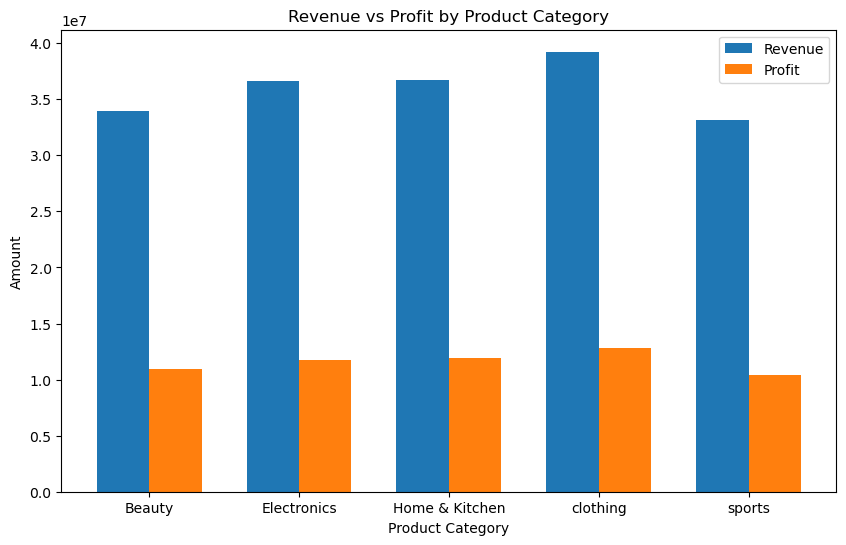

In [68]:
# 11. Compare Revenue and Profit
#Create a grouped bar chart for each product_category.
#For every category show:
#• Revenue
#• Profit
#Requirements:
#• Two bars per category.
#• Different colors.
#• Add legend.
#• Add title and axis labels.
#Concepts: plt.bar(), bar positions, width, plt.xticks()


category_data = df.groupby("product_category")[["revenue", "profit"]].sum()

categories = category_data.index
revenue = category_data["revenue"]
profit = category_data["profit"]

x = np.arange(len(categories))

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    revenue,
    width,
    label="Revenue"
)

plt.bar(
    x + width/2,
    profit,
    width,
    label="Profit"
)

plt.xticks(x, categories)

plt.title("Revenue vs Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount")

plt.legend()

plt.show()

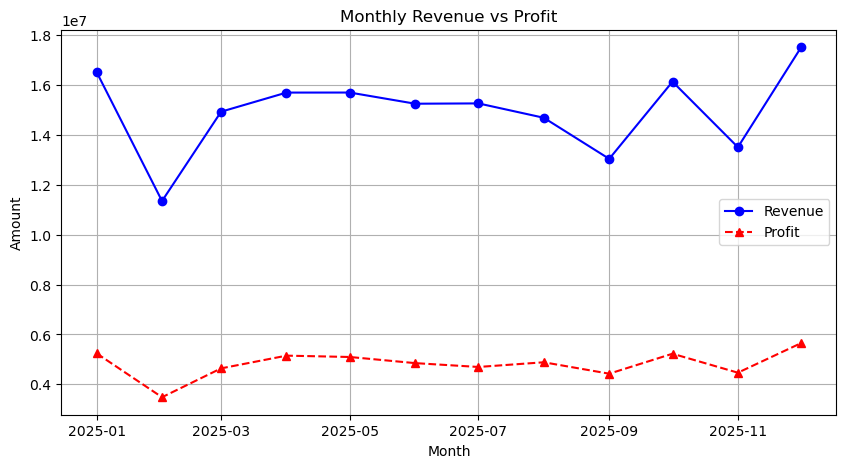

In [69]:
# 12. Monthly Revenue vs Profit
#Create a chart containing two lines:
#• Revenue
#• Profit
#for every month.
#Requirements:
#• Different colors.
#• Different markers.
#• Different line styles.
#• Legend.
#• Grid.
#• Title.
#• X/Y labels.
#Example concept:
#plt.plot(months, revenue)
#plt.plot(months, profit)


monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

monthly_profit = df.groupby(
    df["order_date"].dt.to_period("M")
)["profit"].sum()

monthly_revenue.index = monthly_revenue.index.to_timestamp()
monthly_profit.index = monthly_profit.index.to_timestamp()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    color="blue",
    marker="o",
    linestyle="-",
    label="Revenue"
)

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    color="red",
    marker="^",
    linestyle="--",
    label="Profit"
)

plt.title("Monthly Revenue vs Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.legend()

plt.show()

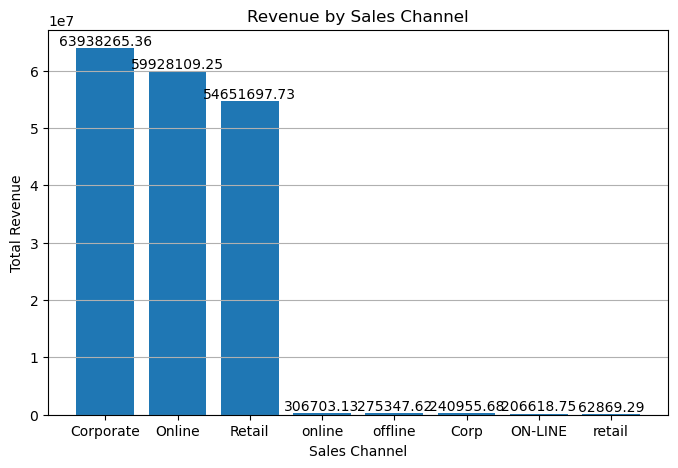

In [70]:
# 13. Sales Channel Comparison
#Calculate total revenue for:
#• Online
#• Retail
#• Corporate
#Create a bar chart.
#Requirements:
#• Add value labels on bars.
#• Sort from highest to lowest.
#• Add title.
#• Add axis labels.
#• Add grid.
#Question: Which sales channel generates the highest revenue?

channel_revenue = df.groupby("sales_channel")["revenue"].sum()

channel_revenue = channel_revenue.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    channel_revenue.index,
    channel_revenue.values
)

plt.title("Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Revenue")
plt.grid(axis="y")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

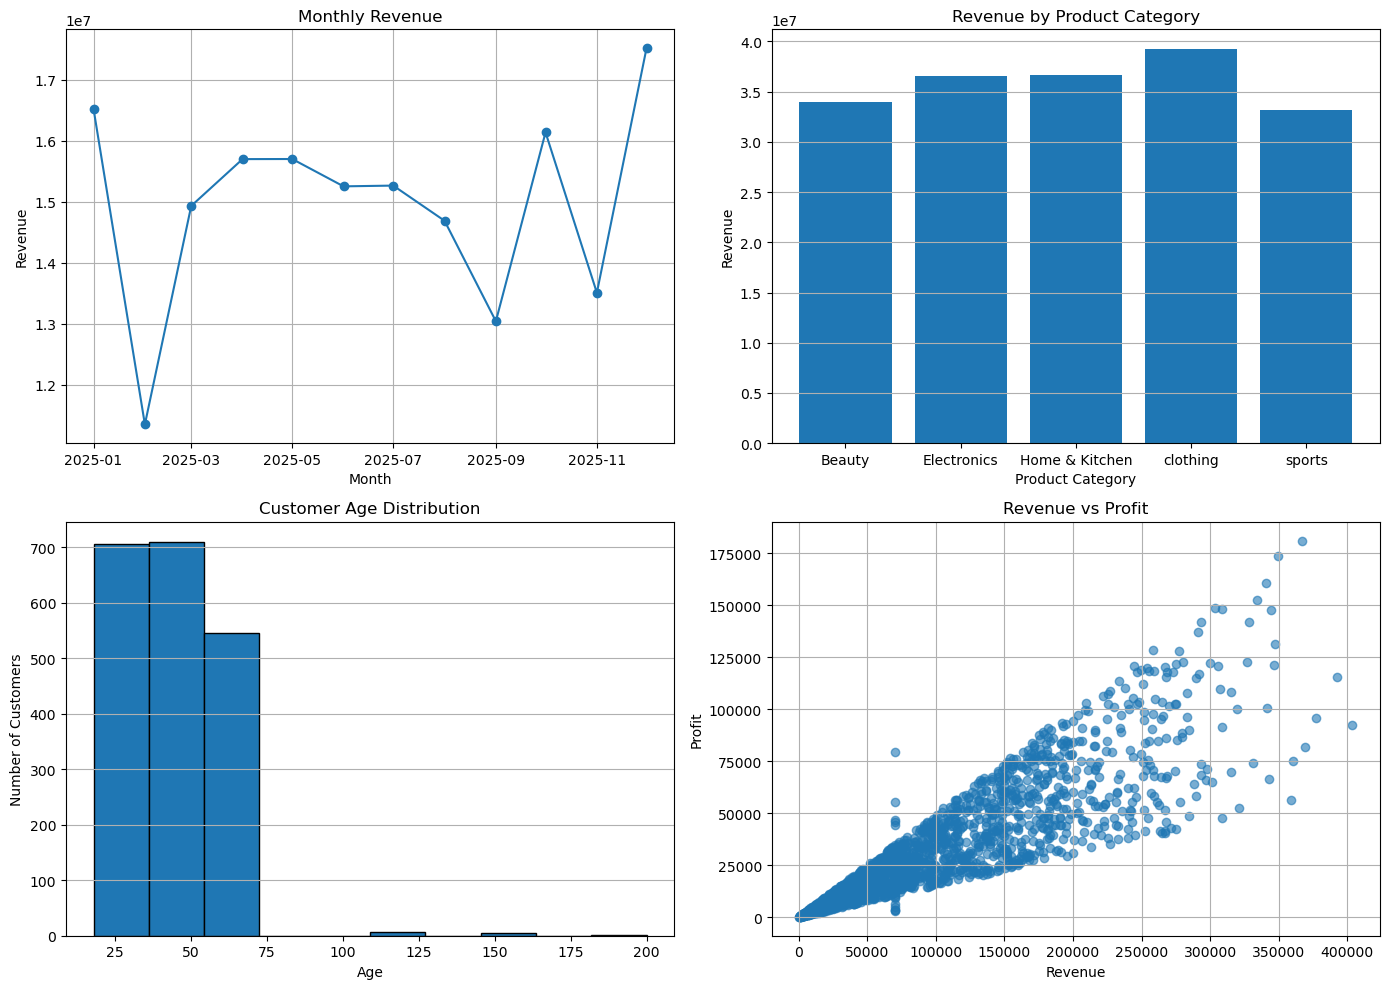

In [71]:
# 14. Four-Chart Matplotlib Dashboard
#Create a 2 × 2 subplot.
#Chart 1
#Monthly Revenue → Line chart
#Chart 2
#Revenue by Category → Bar chart
#Chart 3
#Customer Age → Histogram
#Chart 4
#Revenue vs Profit → Scatter plot
#Use:
#plt.subplots(2, 2)
#Give every subplot:
#• Its own title
#• Appropriate labels
#• Grid where useful
#Finally use:
#plt.tight_layout()

monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

monthly_revenue.index = monthly_revenue.index.to_timestamp()

category_revenue = df.groupby("product_category")["revenue"].sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)

axes[0, 1].bar(
    category_revenue.index,
    category_revenue.values
)

axes[0, 1].set_title("Revenue by Product Category")
axes[0, 1].set_xlabel("Product Category")
axes[0, 1].set_ylabel("Revenue")
axes[0, 1].grid(axis="y")

axes[1, 0].hist(
    df["age"],
    bins=10,
    edgecolor="black"
)

axes[1, 0].set_title("Customer Age Distribution")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Number of Customers")
axes[1, 0].grid(axis="y")

axes[1, 1].scatter(
    df["revenue"],
    df["profit"],
    alpha=0.6
)

axes[1, 1].set_title("Revenue vs Profit")
axes[1, 1].set_xlabel("Revenue")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].grid(True)

plt.tight_layout()

plt.show()

# 15. Final Exam Question — Sales Analysis
Using the complete dataset, create a professional Matplotlib visualization containing:
Chart 1: Monthly Revenue → Line chart
Chart 2: Category Revenue → Bar chart
Chart 3: Revenue Distribution → Histogram
Chart 4: Revenue vs Profit → Scatter plot
Chart 5: Category Revenue Share → Pie chart
For the visual design:
• Add appropriate colors
• Use markers where appropriate
• Add legends
• Add grid
• Add titles

Sumit Sir Notes
• Add X/Y labels
• Use alpha for transparency where appropriate
• Add value labels to bars
• Add percentage labels to pie chart
• Use figsize
• Use tight_layout()
Commands you should practice
plt.figure()
plt.plot()
plt.bar()
plt.barh()
plt.hist()
plt.scatter()
plt.pie()
plt.xlabel()
plt.ylabel()
plt.title()
plt.legend()
plt.grid()
plt.xticks()
plt.yticks()
plt.text()
plt.annotate()
plt.axvline()
plt.subplots()
plt.tight_layout()
plt.show()

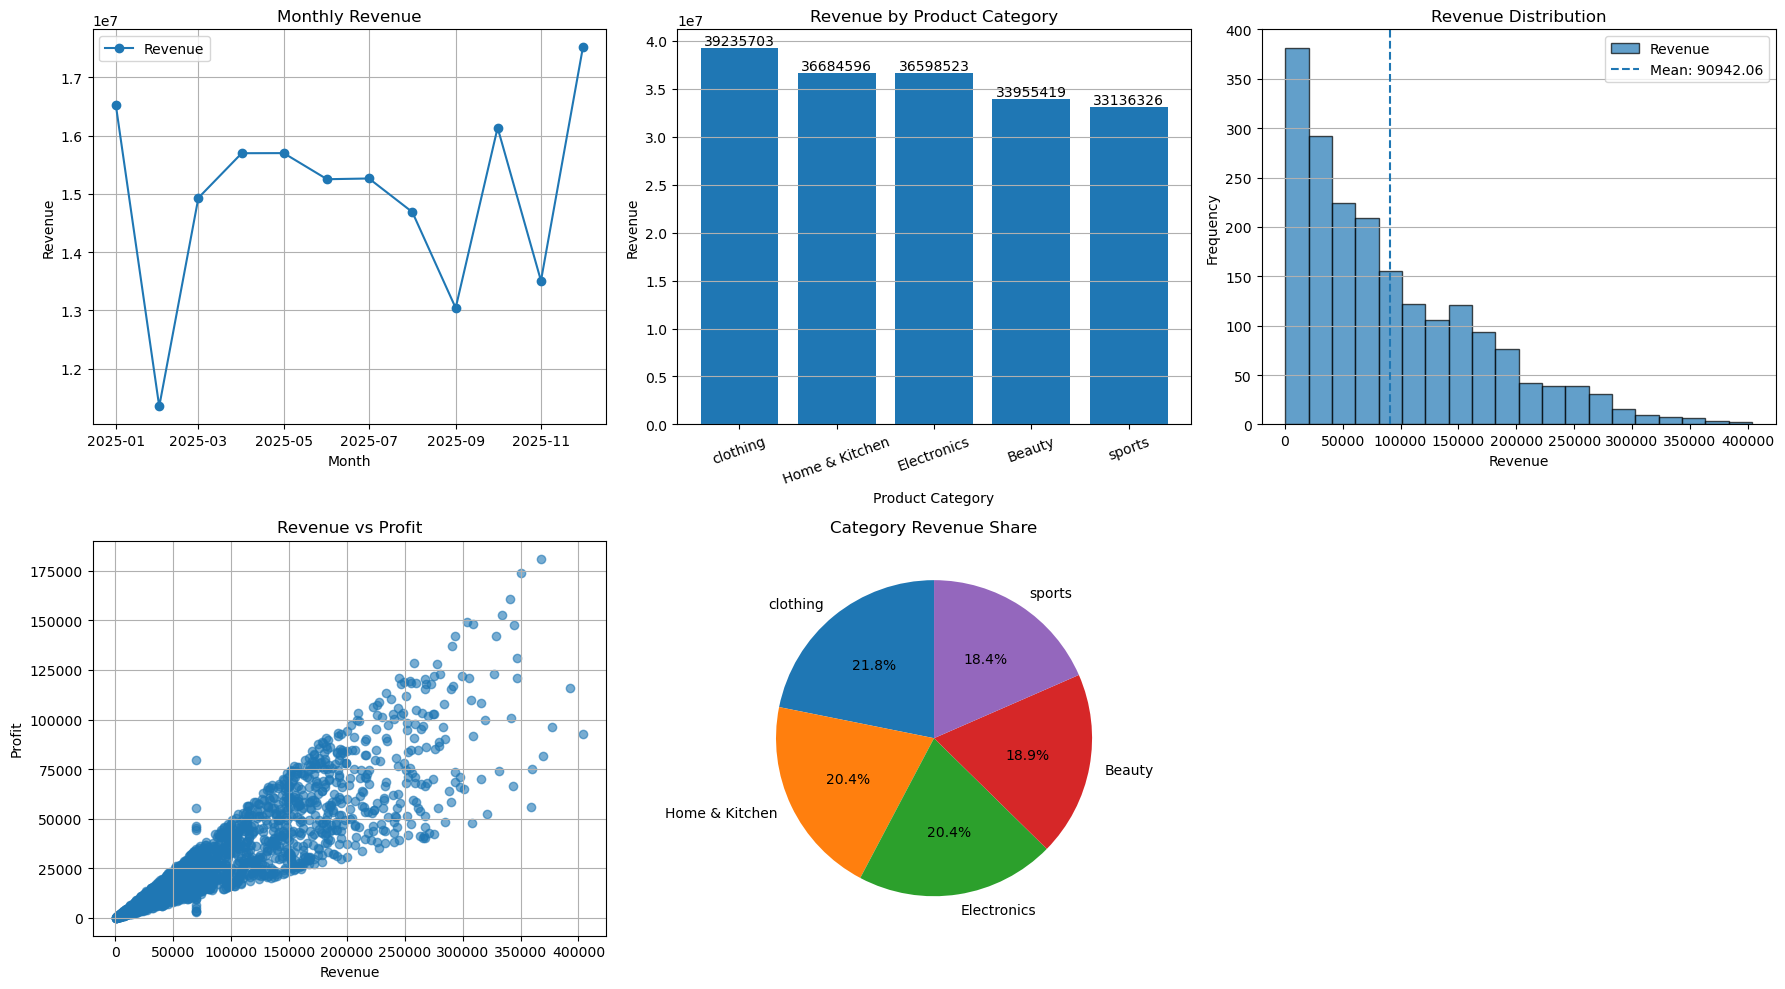

In [72]:

df["order_date"] = pd.to_datetime(df["order_date"])

monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

monthly_revenue.index = monthly_revenue.index.to_timestamp()

category_revenue = df.groupby(
    "product_category"
)["revenue"].sum().sort_values(ascending=False)

revenue = df["revenue"]
profit = df["profit"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linestyle="-",
    label="Revenue"
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)
axes[0, 0].legend()

bars = axes[0, 1].bar(
    category_revenue.index,
    category_revenue.values
)

axes[0, 1].set_title("Revenue by Product Category")
axes[0, 1].set_xlabel("Product Category")
axes[0, 1].set_ylabel("Revenue")
axes[0, 1].grid(axis="y")

axes[0, 1].tick_params(axis="x", rotation=20)

for bar in bars:
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.0f}",
        ha="center",
        va="bottom"
    )

axes[0, 2].hist(
    revenue,
    bins=20,
    alpha=0.7,
    edgecolor="black",
    label="Revenue"
)

mean_revenue = revenue.mean()

axes[0, 2].axvline(
    mean_revenue,
    linestyle="--",
    label=f"Mean: {mean_revenue:.2f}"
)

axes[0, 2].set_title("Revenue Distribution")
axes[0, 2].set_xlabel("Revenue")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].grid(axis="y")
axes[0, 2].legend()


axes[1, 0].scatter(
    revenue,
    profit,
    alpha=0.6,
    marker="o"
)

axes[1, 0].set_title("Revenue vs Profit")
axes[1, 0].set_xlabel("Revenue")
axes[1, 0].set_ylabel("Profit")
axes[1, 0].grid(True)

axes[1, 1].pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[1, 1].set_title("Category Revenue Share")

axes[1, 2].axis("off")

plt.tight_layout()

plt.show()